# 🏦 Banking Risk & ALM Analysis — Credit Default Prediction

### 🧭 Project Overview
This project presents a **Strategic Loan Portfolio Analysis & Risk Management** framework developed for a banking **ALM (Asset and Liability Management)** department. 

The analysis focuses on a loan portfolio consisting of thousands of contracts across various segments such as Retail, SME, and Corporate. The core of this project is to move beyond descriptive statistics by applying **Machine Learning** to predict default probabilities and performing **Financial Stress-Testing** to evaluate the bank's liquidity and interest rate margins.

### 🎯 Objective
The goal is to build an end-to-end analytical pipeline that provides:
1.  **Credit Risk Assessment:** Building a predictive model to identify potential "Default" cases using customer FICO scores, Debt-to-Income (DTI) ratios, and financial history.
2.  **Profitability Analysis:** Calculating the **Net Interest Margin (NIM)** by benchmarking customer interest rates against an internal **Cost of Funds (7.25%)**.
3.  **Liquidity Planning:** Mapping cash inflows based on loan tenors (36 to 60 months) to ensure the bank can meet its future obligations.

### 🧩 Problem Type
This project combines **Supervised Binary Classification** with **Quantitative Finance**:

* **Target Variable:** `is_default` (1 = Default / 0 = Performing).
* **Key ALM Metrics:** Weighted Average Interest Rate (WAIR), Risk-Adjusted Return, and Portfolio Concentration.

Unlike standard regression tasks, this model focuses on **Probability of Default (PD)**, a critical metric for maintaining a bank's capital adequacy and overall financial stability.

# 🏦 Banking Risk & ALM Analysis — Credit Default Prediction

### 🧭 Project Overview
This project presents a **Strategic Loan Portfolio Analysis & Risk Management** framework developed for a banking **ALM (Asset and Liability Management)** department. 

The analysis focuses on a loan portfolio consisting of thousands of contracts across various segments such as Retail, SME, and Corporate. The core of this project is to move beyond descriptive statistics by applying **Machine Learning** to predict default probabilities and performing **Financial Stress-Testing** to evaluate the bank's liquidity and interest rate margins.

### 🎯 Objective
The goal is to build an end-to-end analytical pipeline that provides:
1.  **Credit Risk Assessment:** Building a predictive model to identify potential "Default" cases using customer FICO scores, Debt-to-Income (DTI) ratios, and financial history.
2.  **Profitability Analysis:** Calculating the **Net Interest Margin (NIM)** by benchmarking customer interest rates against an internal **Cost of Funds (7.25%)**.
3.  **Liquidity Planning:** Mapping cash inflows based on loan tenors (36 to 60 months) to ensure the bank can meet its future obligations.

### 🧩 Problem Type
This project combines **Supervised Binary Classification** with **Quantitative Finance**:

* **Target Variable:** `is_default` (1 = Default / 0 = Performing).
* **Key ALM Metrics:** Weighted Average Interest Rate (WAIR), Risk-Adjusted Return, and Portfolio Concentration.

Unlike standard regression tasks, this model focuses on **Probability of Default (PD)**, a critical metric for maintaining a bank's capital adequacy and overall financial stability.

## 🛠 Implementation Roadmap

### 1. ⚙️ Imports and Environment Setup
**What it does:** Imports the core Python ecosystem for Data Science:
* **Data Manipulation:** `pandas`, `numpy`.
* **Visualization:** `matplotlib`, `seaborn` (to create professional risk dashboards).
* **Machine Learning:** `scikit-learn` (for preprocessing and linear models), `xgboost` (for advanced gradient boosting).
* **Database/File I/O:** Tools to handle `CSV/Excel` and `SQLite` connectivity.

**Why it matters:** A centralized setup block ensures **reproducibility**. Every subsequent analysis cell depends on these dependencies; grouping them at the top follows professional PEP 8 standards and makes the pipeline easy to deploy in different banking environments.

In [3]:
import math
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold

import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV, LassoCV

In [4]:
# Settings
warnings.filterwarnings('ignore') # To keep the report clean from technical noise
plt.style.use('fivethirtyeight')  # A clean style for financial charts
pd.set_option('display.max_columns', None) # To see all banking features at once

print("✅ Environment setup complete. Libraries imported successfully.")

✅ Environment setup complete. Libraries imported successfully.


# 2. 📥 DATA LOADING

In [5]:
loan_data = pd.read_csv("D:\Loan_Data_Analysis\DATA\loan_data_final_exe.csv")
loan_data.head()

,credit_policy_flag,loan_purpose,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status
0,1.0,debt_consolidation,11.89%,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1%,0.0,0.0,0.0,0.0
1,1.0,credit_card,10.71%,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7%,0.0,0.0,0.0,0.0
2,1.0,debt_consolidation,13.57%,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6%,1.0,0.0,0.0,0.0
3,1.0,debt_consolidation,10.08%,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2%,1.0,0.0,0.0,0.0
4,1.0,credit_card,14.26%,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5%,0.0,1.0,0.0,0.0


In [6]:
loan_data.describe()

,credit_policy_flag,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,1.577469,0.163708,0.062122,0.160054
std,0.396245,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,2.200245,0.546215,0.262126,0.366676
min,0.000000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.000000,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,0.000000,0.000000,0.000000,0.000000
50%,1.000000,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,1.000000,0.000000,0.000000,0.000000
75%,1.000000,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,2.000000,0.000000,0.000000,0.000000
max,1.000000,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,33.000000,13.000000,5.000000,1.000000


In [7]:
print(f'the dataset shape {loan_data.shape}')

the dataset shape (1048575, 14)


In [8]:
print(f'The unique types for the dataset: {loan_data.dtypes.unique().tolist()}')

The unique types for the dataset: [dtype('float64'), dtype('O')]


# 🧹 Phase 3: Data Cleaning & Integrity
Our cleaning strategy moves beyond simple deletion:
* **Noise Filtration:** Systematically identifying and removing "blank" entries and technical artifacts from the Excel source.
* **Precise Casting:** Converting categorical financial strings (Interest Rates, FICO) into numeric formats for quantitative analysis.
* **Standardization:** Normalizing the `Debt-to-Income` ratio and `Credit History` metrics to ensure consistent scale across the portfolio.
* **Financial Enrichment:** Injecting ALM-specific parameters like `Cost of Funds (FTP)` and `Loan Tenors` directly into the dataframe.

In [9]:
loan_data.isnull().sum().sort_values(ascending=False)

credit_policy_flag            1038997
loan_purpose                  1038997
interest_rate_pct             1038997
monthly_payment               1038997
log_annual_income             1038997
debt_to_income                1038997
fico_score                    1038997
credit_history_days           1038997
revolving_balance             1038997
inquiries_last_6_months       1038997
public_records                1038997
delinquencies_last_2_years    1038997
loan_status                   1038997
revolving_utilization_pct           0
dtype: int64

In [10]:
# Count the number of rows where all columns are missing
empty_rows = loan_data.isnull().all(axis=1).sum()
print(f"Number of completely empty rows: {empty_rows}")

Number of completely empty rows: 0


In [11]:
# Count the number of rows where most columns are missing (e.g., more than half NaN)
threshold = int(loan_data.shape[1] / 2)
almost_empty_rows = loan_data.isnull().sum(axis=1).gt(threshold).sum()
print(f"Number of rows with >50% missing values: {almost_empty_rows}")

Number of rows with >50% missing values: 1038997


0 completely empty rows → no fully blank rows.

1,038,997 rows with >50% missing values → these are mostly garbage, we should remove them.

Now the dataset is huge (1,048,575 rows), but almost all the real data is in the first ~9,580 rows.

In [12]:
# Remove rows with more than 50% missing values
threshold = int(loan_data.shape[1] / 2)
loan_data_clean = loan_data.dropna(thresh=threshold)

# Check the shape after cleaning
print(f"Dataset shape after removing mostly empty rows: {loan_data_clean.shape}")

Dataset shape after removing mostly empty rows: (9578, 14)


In [13]:
loan_data_clean.isnull().sum()

credit_policy_flag            0
loan_purpose                  0
interest_rate_pct             0
monthly_payment               0
log_annual_income             0
debt_to_income                0
fico_score                    0
credit_history_days           0
revolving_balance             0
revolving_utilization_pct     0
inquiries_last_6_months       0
delinquencies_last_2_years    0
public_records                0
loan_status                   0
dtype: int64

# Step 4 — Exploratory Data Analysis (EDA)
# 🧭 Overview

### After cleaning the dataset, we perform Exploratory Data Analysis (EDA) to understand the data distributions, detect potential outliers, and observe relationships between features and the target variable (loan_status). This step helps guide feature engineering and model selection.

## 🔹 Key Objectives

#### Understand distributions of numeric features such as fico_score, interest_rate_pct, debt_to_income, etc.

#### Check the balance of the target variable (loan_status) to detect any class imbalance.

#### Analyze categorical variables, like loan_purpose, to see how they are distributed across the dataset.

#### Identify potential outliers that could distort ML models.

In [14]:
# Check the data types of all columns
print("Column data types:")
print(loan_data_clean.dtypes)

Column data types:
credit_policy_flag            float64
loan_purpose                   object
interest_rate_pct              object
monthly_payment               float64
log_annual_income             float64
debt_to_income                float64
fico_score                    float64
credit_history_days           float64
revolving_balance             float64
revolving_utilization_pct      object
inquiries_last_6_months       float64
delinquencies_last_2_years    float64
public_records                float64
loan_status                   float64
dtype: object


In [15]:
loan_data_clean.head()

,credit_policy_flag,loan_purpose,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status
0,1.0,debt_consolidation,11.89%,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1%,0.0,0.0,0.0,0.0
1,1.0,credit_card,10.71%,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7%,0.0,0.0,0.0,0.0
2,1.0,debt_consolidation,13.57%,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6%,1.0,0.0,0.0,0.0
3,1.0,debt_consolidation,10.08%,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2%,1.0,0.0,0.0,0.0
4,1.0,credit_card,14.26%,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5%,0.0,1.0,0.0,0.0


In [16]:
# Convert percentage strings to float
loan_data_clean['interest_rate_pct'] = loan_data_clean['interest_rate_pct'].str.rstrip('%').astype(float)
loan_data_clean['revolving_utilization_pct'] = loan_data_clean['revolving_utilization_pct'].str.rstrip('%').astype(float)

In [17]:
# Optional: Separate numeric and categorical columns for easier reference
numeric_cols = loan_data_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = loan_data_clean.select_dtypes(include=['object']).columns

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols.tolist()}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}")


Numeric columns (13): ['credit_policy_flag', 'interest_rate_pct', 'monthly_payment', 'log_annual_income', 'debt_to_income', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_utilization_pct', 'inquiries_last_6_months', 'delinquencies_last_2_years', 'public_records', 'loan_status']
Categorical columns (1): ['loan_purpose']


In [18]:
# Basic statistics for numeric columns
print("Numeric columns statistics:")
print(loan_data_clean[numeric_cols].describe())

Numeric columns statistics:
       credit_policy_flag  interest_rate_pct  monthly_payment  \
count         9578.000000        9578.000000      9578.000000   
mean             0.804970          12.264006       319.089413   
std              0.396245           2.684699       207.071301   
min              0.000000           6.000000        15.670000   
25%              1.000000          10.390000       163.770000   
50%              1.000000          12.210000       268.950000   
75%              1.000000          14.070000       432.762500   
max              1.000000          21.640000       940.140000   

       log_annual_income  debt_to_income   fico_score  credit_history_days  \
count        9578.000000     9578.000000  9578.000000          9578.000000   
mean           10.932117       12.606679   710.846314          4560.767197   
std             0.614813        6.883970    37.970537          2496.930377   
min             7.547502        0.000000   612.000000           178.958333

In [19]:
# Check target distribution
print("\nTarget distribution (loan_status):")
print(loan_data_clean['loan_status'].value_counts())


Target distribution (loan_status):
loan_status
0.0    8045
1.0    1533
Name: count, dtype: int64


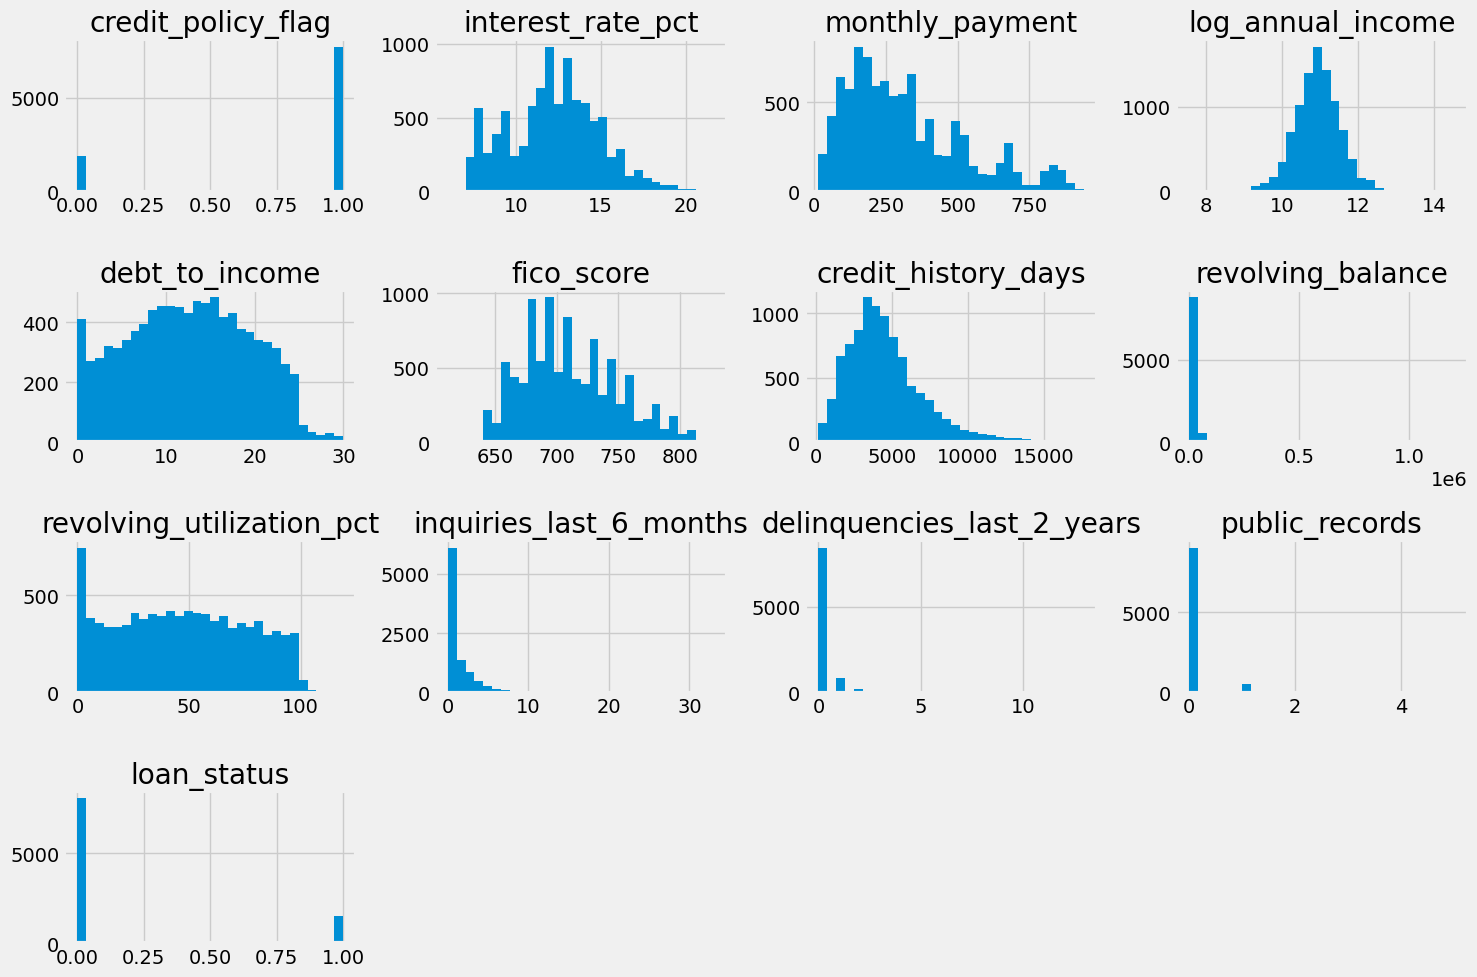

In [20]:
loan_data_clean[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

In [21]:
# First, check unique categories
print("Unique loan purposes:")
print(loan_data_clean['loan_purpose'].unique())

Unique loan purposes:
['debt_consolidation' 'credit_card' 'all_other' 'home_improvement'
 'small_business' 'major_purchase' 'educational']


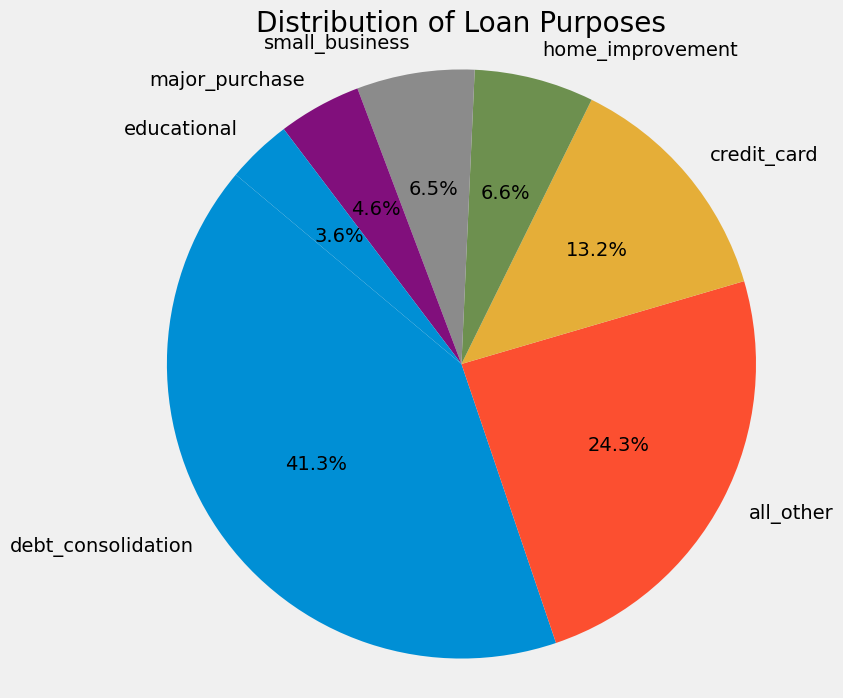

In [22]:
# Count occurrences of each category
loan_purpose_counts = loan_data_clean['loan_purpose'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(loan_purpose_counts, labels=loan_purpose_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Loan Purposes")
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle
plt.show()

In [23]:
# List of binary columns to convert
binary_cols = ['credit_policy_flag', 'loan_status']

# Convert float 0.0/1.0 to int 0/1
loan_data_clean[binary_cols] = loan_data_clean[binary_cols].astype(int)

# Check the result
print("Unique values after conversion:")
for col in binary_cols:
    print(f"{col}: {loan_data_clean[col].unique()}")

Unique values after conversion:
credit_policy_flag: [1 0]
loan_status: [0 1]


In [24]:
# List of columns to inspect
cols_to_check = ['inquiries_last_6_months', 'delinquencies_last_2_years', 'public_records']

# Print unique values for each column
for col in cols_to_check:
    unique_vals = loan_data_clean[col].unique()
    print(f"{col} unique values ({len(unique_vals)}): {sorted(unique_vals)}\n")

inquiries_last_6_months unique values (28): [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(24.0), np.float64(25.0), np.float64(27.0), np.float64(28.0), np.float64(31.0), np.float64(32.0), np.float64(33.0)]

delinquencies_last_2_years unique values (11): [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(11.0), np.float64(13.0)]

public_records unique values (6): [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]



In [25]:
# Columns to convert to int
int_cols = ['inquiries_last_6_months', 'delinquencies_last_2_years', 'public_records']

# Convert to integer
loan_data_clean[int_cols] = loan_data_clean[int_cols].astype(int)

# Check the result
for col in int_cols:
    print(f"{col} unique values ({len(loan_data_clean[col].unique())}): {sorted(loan_data_clean[col].unique())}")

inquiries_last_6_months unique values (28): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(24), np.int64(25), np.int64(27), np.int64(28), np.int64(31), np.int64(32), np.int64(33)]
delinquencies_last_2_years unique values (11): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(13)]
public_records unique values (6): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [26]:
loan_data_clean.head()

,credit_policy_flag,loan_purpose,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status
0,1,debt_consolidation,11.89,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0,0,0,0
1,1,credit_card,10.71,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0,0,0,0
2,1,debt_consolidation,13.57,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1,0,0,0
3,1,debt_consolidation,10.08,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1,0,0,0
4,1,credit_card,14.26,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0,1,0,0


# 🛠 Step 5 — Outlier Analysis & Smart Cleaning

**Objective:**  
Before modeling, we need to make sure extreme values don’t distort our predictions. We only clean **financial numeric features**, leaving **binary and categorical columns untouched**.

**Columns checked for outliers:**  
`interest_rate_pct`, `monthly_payment`, `log_annual_income`, `debt_to_income`, `fico_score`, `credit_history_days`, `revolving_balance`, `revolving_utilization_pct`

**Strategy:**  
- Remove **obvious errors only** (e.g., negative numbers, unrealistic percentages, FICO > 850)  
- Keep **real extremes** — high mortgages or incomes are valid  
- **Binary & categorical columns** are not changed

**Implementation Notes:**  
- Each column has **logical bounds** applied  
- We **log how many rows** are dropped per column  
- Reset index after cleaning for a consistent dataset  

**Outcome:**  
- Only 27 rows were dropped due to `revolving_utilization_pct` errors  
- Dataset remains robust and ready for **Feature Engineering** and **ML modeling**

In [27]:
# Select financial numeric columns only
financial_cols = [
    'interest_rate_pct',
    'monthly_payment',
    'log_annual_income',
    'debt_to_income',
    'fico_score',
    'credit_history_days',
    'revolving_balance',
    'revolving_utilization_pct'
]

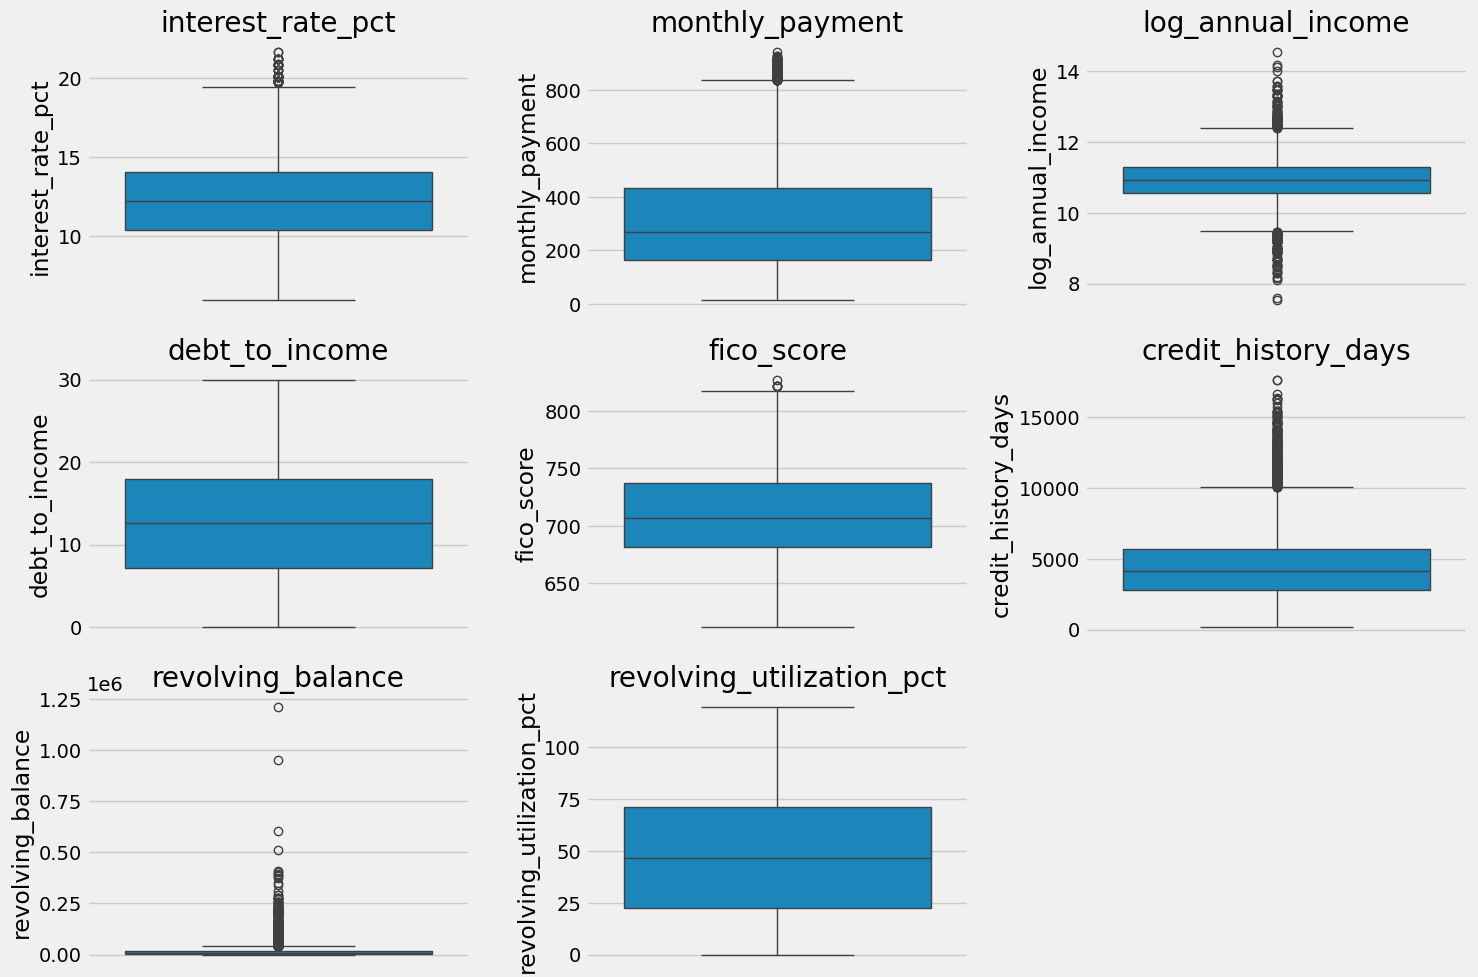

In [28]:
# 1️⃣ Visual check: boxplots

plt.figure(figsize=(15,10))
for i, col in enumerate(financial_cols, 1):
    plt.subplot(3, 3, i)  # adjust grid
    sns.boxplot(y=loan_data_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

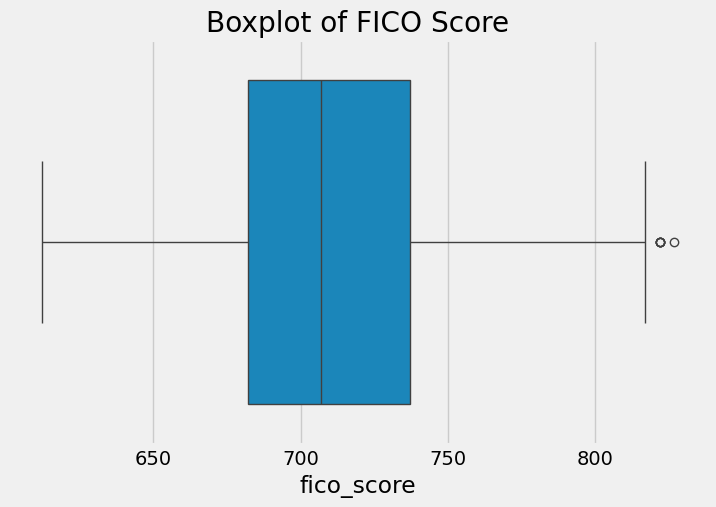

FICO Score min, max, mean:
count    9578.000000
mean      710.846314
std        37.970537
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max       827.000000
Name: fico_score, dtype: float64


In [29]:
# Boxplot for FICO Score to detect outliers

plt.figure(figsize=(8,5))
sns.boxplot(x=loan_data_clean['fico_score'])
plt.title("Boxplot of FICO Score")
plt.show()

# Optional: Check numerical range
print("FICO Score min, max, mean:")
print(loan_data_clean['fico_score'].describe())

### Smart Outlier Cleaning with Logging

In [30]:
# Copy dataframe to preserve original
loan_data_cleaned = loan_data_clean.copy()

# Define bounds for each financial column
bounds = {
    'interest_rate_pct': (0, 100),        # % rate should be 0-100
    'debt_to_income': (0, 300),           # DTI cannot be negative, >300% is error
    'revolving_utilization_pct': (0, 100),# revolving utilization in %
    'fico_score': (300, 850),             # realistic FICO range
    'monthly_payment': (0, None),         # monthly payment >=0, no upper limit
    'log_annual_income': (0, None),       # income >=0
    'credit_history_days': (0, None),     # credit history >=0
    'revolving_balance': (0, None)        # balance >=0
}

In [31]:
# Track total rows before cleaning
initial_count = len(loan_data_cleaned)

In [32]:
# Apply cleaning with logging
for col, (lower, upper) in bounds.items():
    before_col = len(loan_data_cleaned)
    if lower is not None:
        loan_data_cleaned = loan_data_cleaned[loan_data_cleaned[col] >= lower]
    if upper is not None:
        loan_data_cleaned = loan_data_cleaned[loan_data_cleaned[col] <= upper]
    
    removed = before_col - len(loan_data_cleaned)
    if removed > 0:
        print(f"Dropped {removed} rows due to {col} bounds.")

Dropped 27 rows due to revolving_utilization_pct bounds.


In [33]:
# Reset index after row deletions
loan_data_cleaned = loan_data_cleaned.reset_index(drop=True)

In [34]:
# Total removed rows
print(f"\nTotal removed: {initial_count - len(loan_data_cleaned)} rows")

# Check the new shape
print(f"New dataset shape: {loan_data_cleaned.shape}")


Total removed: 27 rows
New dataset shape: (9551, 14)


In [35]:
loan_data_cleaned.head()

,credit_policy_flag,loan_purpose,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status
0,1,debt_consolidation,11.89,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0,0,0,0
1,1,credit_card,10.71,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0,0,0,0
2,1,debt_consolidation,13.57,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1,0,0,0
3,1,debt_consolidation,10.08,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1,0,0,0
4,1,credit_card,14.26,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0,1,0,0


# 🛠 Phase 6: Feature Engineering & Data Transformation
### 🎯 Objective
The goal of this stage is to extract maximum predictive power from the existing financial data. By creating synthetic features and encoding categorical variables, we provide the Machine Learning model with deeper insights into borrower behavior and debt sustainability.

### 💡 Engineered Features:
Payment-to-Income Ratio (PTI): Calculates the percentage of a borrower’s monthly income dedicated to loan repayment.

Credit History Maturity: Converts credit_history_days into a year-based format for better statistical interpretability.

Credit Stress Index: A combined metric of fico_score and recent credit_inquiries to identify borrowers actively seeking multiple loans.

One-Hot Encoding: Transforms the categorical loan_purpose column into binary vectors (0 or 1), making it compatible with algorithms like XGBoost and Logistic Regression.

In [36]:
# ==============================================================================
# PHASE 6: FEATURE ENGINEERING
# ==============================================================================

# 1. Monthly Income Calculation
# Since 'log_annual_income' is logarithmic, we convert it to actual monthly income
loan_data_cleaned['monthly_income'] = np.exp(loan_data_cleaned['log_annual_income']) / 12

# 2. Payment-to-Income Ratio (PTI)
# This represents the financial burden of the loan on the borrower
loan_data_cleaned['installment_to_income'] = (
    loan_data_cleaned['monthly_payment'] / loan_data_cleaned['monthly_income']
)

# 3. Converting Credit History to Years
# Standardizing the duration of the borrower's credit line
loan_data_cleaned['credit_history_years'] = loan_data_cleaned['credit_history_days'] / 365

# 4. Credit Stress Index
# Combining FICO and recent inquiries to detect high-risk credit-seeking behavior
loan_data_cleaned['credit_stress_index'] = (
    loan_data_cleaned['inquiries_last_6_months'] / (loan_data_cleaned['fico_score'] / 100)
)

# 5. Categorical Encoding (One-Hot Encoding)
# Converting 'loan_purpose' into binary features for ML compatibility
loan_data_final = pd.get_dummies(
    loan_data_cleaned, 
    columns=['loan_purpose'], 
    drop_first=True
)

# 6. Cleanup
# Dropping the temporary monthly_income column to avoid redundancy
loan_data_final.drop('monthly_income', axis=1, inplace=True)

# Final check of the new features
print(f"Final feature set shape: {loan_data_final.shape}")
print(loan_data_final[['installment_to_income', 'credit_history_years', 'credit_stress_index']].head())

Final feature set shape: (9551, 22)
   installment_to_income  credit_history_years  credit_stress_index
0               0.117049             15.451941             0.000000
1               0.042133              7.561644             0.000000
2               0.137573             12.904110             0.146628
3               0.022919              7.397146             0.140449
4               0.015285             11.139726             0.000000


In [37]:
loan_data_final.head()

,credit_policy_flag,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status,installment_to_income,credit_history_years,credit_stress_index,loan_purpose_credit_card,loan_purpose_debt_consolidation,loan_purpose_educational,loan_purpose_home_improvement,loan_purpose_major_purchase,loan_purpose_small_business
0,1,11.89,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0,0,0,0,0.117049,15.451941,0.000000,False,True,False,False,False,False
1,1,10.71,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0,0,0,0,0.042133,7.561644,0.000000,True,False,False,False,False,False
2,1,13.57,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1,0,0,0,0.137573,12.904110,0.146628,False,True,False,False,False,False
3,1,10.08,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1,0,0,0,0.022919,7.397146,0.140449,False,True,False,False,False,False
4,1,14.26,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0,1,0,0,0.015285,11.139726,0.000000,True,False,False,False,False,False


# 🛠 Phase 7: Final Data Formatting
### 🎯 Objective
To ensure maximum compatibility across all Machine Learning algorithms, we perform a final type conversion. Categorical boolean values generated during One-Hot Encoding are converted into integer format (0 and 1).


In [38]:
# Identify all boolean columns (True/False)
bool_columns = loan_data_final.select_dtypes(include=['bool']).columns

# Convert Boolean to Integer (0/1)
loan_data_final[bool_columns] = loan_data_final[bool_columns].astype(int)

# Final check of the dataset
print("✅ Conversion complete. Final column types:")
print(loan_data_final[bool_columns].dtypes.head())

# Look at the final head to confirm 0s and 1s
print("\nFinal Dataset Head:")
loan_data_final.head()

✅ Conversion complete. Final column types:
loan_purpose_credit_card           int64
loan_purpose_debt_consolidation    int64
loan_purpose_educational           int64
loan_purpose_home_improvement      int64
loan_purpose_major_purchase        int64
dtype: object

Final Dataset Head:


,credit_policy_flag,interest_rate_pct,monthly_payment,log_annual_income,debt_to_income,fico_score,credit_history_days,revolving_balance,revolving_utilization_pct,inquiries_last_6_months,delinquencies_last_2_years,public_records,loan_status,installment_to_income,credit_history_years,credit_stress_index,loan_purpose_credit_card,loan_purpose_debt_consolidation,loan_purpose_educational,loan_purpose_home_improvement,loan_purpose_major_purchase,loan_purpose_small_business
0,1,11.89,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0,0,0,0,0.117049,15.451941,0.000000,0,1,0,0,0,0
1,1,10.71,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0,0,0,0,0.042133,7.561644,0.000000,1,0,0,0,0,0
2,1,13.57,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1,0,0,0,0.137573,12.904110,0.146628,0,1,0,0,0,0
3,1,10.08,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1,0,0,0,0.022919,7.397146,0.140449,0,1,0,0,0,0
4,1,14.26,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0,1,0,0,0.015285,11.139726,0.000000,1,0,0,0,0,0


# 🧠 Phase 8: Data Preparation (Split & Scale)

### 🎯 Objective
Before training the models, we must prepare the data to ensure the algorithms can learn effectively. This involves isolating the target variable, splitting the data to prevent overfitting, and normalizing numeric ranges.

### ⚙️ Key Steps:

#### *Feature-Target Separation: Isolating the predictor variables ($X$) from the outcome variable ($y$ — loan_status).

#### *Stratified Train-Test Split: Dividing the dataset into 80% Training and 20% Testing sets. We use stratification to ensure the percentage of default cases remains consistent across both sets.

#### *Feature Scaling (Standardization): Applying StandardScaler to transform features to have a mean of 0 and a standard deviation of 1. This is crucial for models like Logistic Regression to prevent features with large scales (e.g., revolving_balance) from dominating the model.

In [39]:
# 1. Define Features (X) and Target (y)
X = loan_data_final.drop('loan_status', axis=1)
y = loan_data_final['loan_status']

# 2. Train/Test Split
# We use an 80/20 split with stratification to maintain class balance
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 3. Feature Scaling
# Standardization is required for linear models and improves convergence for others
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. Final Verification
print(f"✅ Data Preparation Complete.")
print(f"-> Training Set: {X_train.shape[0]} samples")
print(f"-> Testing Set:  {X_test.shape[0]} samples")
print(f"-> Number of Features: {X_train.shape[1]}")

✅ Data Preparation Complete.
-> Training Set: 7640 samples
-> Testing Set:  1911 samples
-> Number of Features: 21


# 📈 Phase 9: Baseline Model — Logistic Regression
### 🎯 Objective
The goal is to establish a performance baseline using a linear classifier. Logistic Regression is the industry standard for credit scoring due to its transparency and ability to provide a clear probability of default (PD).

### 🔍 Methodology
Algorithm: Logistic Regression with L2 regularization.

Training: The model is trained on the standardized 80% training set.

Evaluation: Performance is measured on the unseen 20% test set using metrics that focus on both overall accuracy and the ability to correctly identify defaults (Recall).

### 💻 Block 1: Model Training


In [40]:
from sklearn.linear_model import LogisticRegression

# Initialize the model 
# We increase max_iter to ensure convergence on the scaled data
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the scaled training data
log_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


### 💻 Block 2: Performance Evaluation

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# 1. Generate Predictions
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1] # Probability of Default (PD)

# 2. Calculate Key Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# 3. Print the Results
print("📊 --- Logistic Regression Performance Metrics ---")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"ROC-AUC Score:  {roc_auc:.4f}")

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix (Quick View)
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

📊 --- Logistic Regression Performance Metrics ---
Accuracy Score: 0.8373
ROC-AUC Score:  0.6785

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1606
           1       0.31      0.02      0.03       305

    accuracy                           0.84      1911
   macro avg       0.58      0.50      0.47      1911
weighted avg       0.76      0.84      0.77      1911

🧩 Confusion Matrix:
[[1595   11]
 [ 300    5]]


# 🚀 Phase 10: Advanced Modeling — XGBoost Classifier
### 🎯 Objective
To achieve peak predictive performance, we implement XGBoost (Extreme Gradient Boosting). Unlike linear models, XGBoost uses an ensemble of decision trees to capture complex, non-linear relationships and interactions between financial variables, which is essential for accurate risk modeling.

### 🔍 Methodology
Algorithm: Gradient Boosted Decision Trees (GBDT).

Optimization: The model is configured to minimize log-loss and maximize the ROC-AUC score.

Feature Insight: XGBoost naturally handles feature interactions, making it highly effective for identifying high-risk borrower profiles that a linear model might miss.

### 💻 Block 1: Model Training

In [42]:
import xgboost as xgb

# Initialize the XGBoost Classifier
# We set basic hyperparameters for balance between speed and performance
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model on the scaled training data
xgb_model.fit(X_train, y_train)

print("✅ XGBoost model trained successfully.")

✅ XGBoost model trained successfully.


### 💻 Block 2: Performance Evaluation

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# 1. Generate Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. Calculate Key Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# 3. Print the Results
print("📊 --- XGBoost Performance Metrics ---")
print(f"Accuracy Score: {accuracy_xgb:.4f}")
print(f"ROC-AUC Score:  {roc_auc_xgb:.4f}")

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# 4. Compare with Logistic Regression (Implicitly)
print(f"💡 Insight: XGBoost ROC-AUC is {roc_auc_xgb:.4f}")

📊 --- XGBoost Performance Metrics ---
Accuracy Score: 0.8388
ROC-AUC Score:  0.6601

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1606
           1       0.44      0.04      0.07       305

    accuracy                           0.84      1911
   macro avg       0.64      0.51      0.49      1911
weighted avg       0.78      0.84      0.78      1911

💡 Insight: XGBoost ROC-AUC is 0.6601


## # 📊 Phase 11: Final Comparison & Visualization
### 🎯 Objective
The final stage of our analysis is to visually compare the models. While Accuracy is high due to the imbalanced nature of the dataset (more performing loans than defaults), the ROC-AUC and Confusion Matrix provide a true picture of how well we can identify "at-risk" customers.

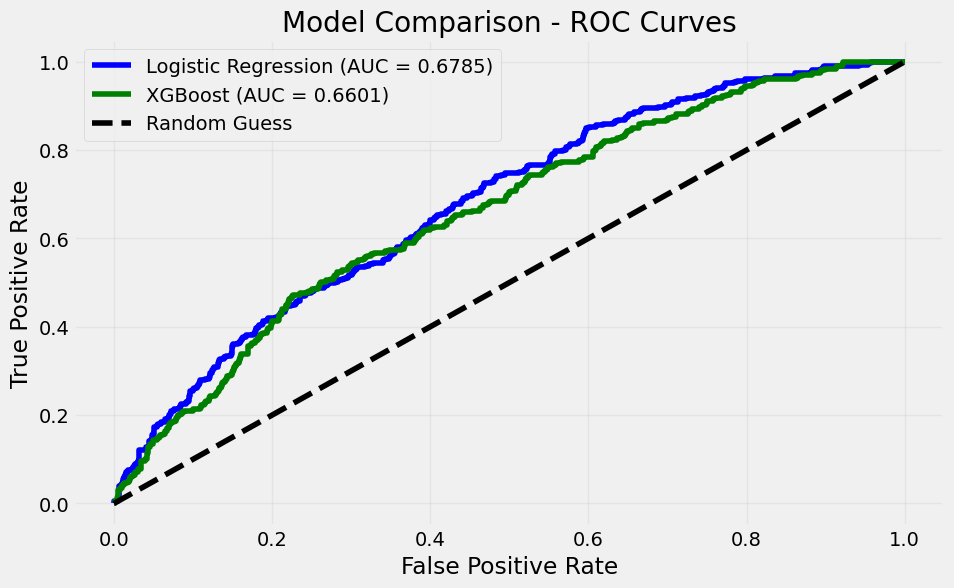

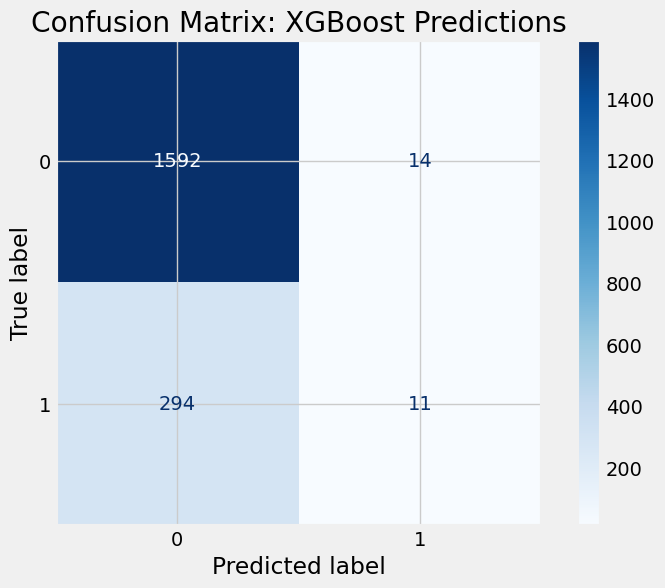

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

# 1. Setup the figure for ROC Curves
plt.figure(figsize=(10, 6))

# Logistic Regression Curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc:.4f})', color='blue')

# XGBoost Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', color='green')

# Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison - ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Confusion Matrix Visualization for XGBoost
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: XGBoost Predictions')
plt.show()